In [1]:
#!pip install --upgrade scikit-learn

In [2]:
from sklearn import set_config
set_config(display='text')

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('model_data.csv')

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [5]:
df = pd.read_csv('model_data.csv')

In [6]:
#choose relevant colunms 
#get dummy data
#train test split 
#multiple linear regression 
#lasso regeression
# Random Forest
# Tune models GridsearchCV
# test ensembles

In [7]:
#choose relevant colunms 
df.columns
df_model = df[['avg_salary','Rating','Size','Type of ownership','Industry','Sector','Revenue','num_comp','hourly','employer_provided',
               'job_state','same_state','age','python_yn','spark','excel','job_simp','seniority','desc_len']]

In [8]:
#get dummy data
df_dum = pd.get_dummies(df_model)
df_dum

,avg_salary,Rating,num_comp,hourly,employer_provided,same_state,age,python_yn,spark,excel,...,job_simp_analyst,job_simp_data engineer,job_simp_data scientist,job_simp_director,job_simp_manager,job_simp_mle,job_simp_na,seniority_jr,seniority_na,seniority_senior
0,72.0,3.8,1,0,0,0,47,1,0,1,...,False,False,True,False,False,False,False,False,True,False
1,87.5,3.4,1,0,0,0,36,1,0,0,...,False,False,True,False,False,False,False,False,True,False
2,85.0,4.8,1,0,0,1,10,1,1,1,...,False,False,True,False,False,False,False,False,True,False
3,76.5,3.8,3,0,0,1,55,1,0,0,...,False,False,True,False,False,False,False,False,True,False
4,114.5,2.9,3,0,0,1,22,1,0,1,...,False,False,True,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
737,84.5,3.9,3,0,0,0,190,0,0,0,...,False,False,False,False,False,False,True,False,False,True
738,102.5,4.4,3,0,0,0,14,1,1,0,...,False,True,False,False,False,False,False,False,False,True
739,73.5,2.6,1,0,0,1,36,0,0,1,...,False,False,False,False,False,False,True,False,True,False
740,127.5,3.2,1,0,0,0,-1,0,0,1,...,False,False,False,False,True,False,False,False,True,False


In [9]:
#train test split 
# from sklearn.model_selection import train_test_split
# X = df_dum.drop('avg_salary',axis = 1)
# Y = df_dum.avg_salary.values

# X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [10]:
df_dum

,avg_salary,Rating,num_comp,hourly,employer_provided,same_state,age,python_yn,spark,excel,...,job_simp_analyst,job_simp_data engineer,job_simp_data scientist,job_simp_director,job_simp_manager,job_simp_mle,job_simp_na,seniority_jr,seniority_na,seniority_senior
0,72.0,3.8,1,0,0,0,47,1,0,1,...,False,False,True,False,False,False,False,False,True,False
1,87.5,3.4,1,0,0,0,36,1,0,0,...,False,False,True,False,False,False,False,False,True,False
2,85.0,4.8,1,0,0,1,10,1,1,1,...,False,False,True,False,False,False,False,False,True,False
3,76.5,3.8,3,0,0,1,55,1,0,0,...,False,False,True,False,False,False,False,False,True,False
4,114.5,2.9,3,0,0,1,22,1,0,1,...,False,False,True,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
737,84.5,3.9,3,0,0,0,190,0,0,0,...,False,False,False,False,False,False,True,False,False,True
738,102.5,4.4,3,0,0,0,14,1,1,0,...,False,True,False,False,False,False,False,False,False,True
739,73.5,2.6,1,0,0,1,36,0,0,1,...,False,False,False,False,False,False,True,False,True,False
740,127.5,3.2,1,0,0,0,-1,0,0,1,...,False,False,False,False,True,False,False,False,True,False


In [11]:
df_dum = df_dum.replace({'True': True, 'False': False})
bool_cols = df_dum.select_dtypes(include='bool').columns
df_dum[bool_cols] = df_dum[bool_cols].astype(int)

In [12]:
df_dum

,avg_salary,Rating,num_comp,hourly,employer_provided,same_state,age,python_yn,spark,excel,...,job_simp_analyst,job_simp_data engineer,job_simp_data scientist,job_simp_director,job_simp_manager,job_simp_mle,job_simp_na,seniority_jr,seniority_na,seniority_senior
0,72.0,3.8,1,0,0,0,47,1,0,1,...,0,0,1,0,0,0,0,0,1,0
1,87.5,3.4,1,0,0,0,36,1,0,0,...,0,0,1,0,0,0,0,0,1,0
2,85.0,4.8,1,0,0,1,10,1,1,1,...,0,0,1,0,0,0,0,0,1,0
3,76.5,3.8,3,0,0,1,55,1,0,0,...,0,0,1,0,0,0,0,0,1,0
4,114.5,2.9,3,0,0,1,22,1,0,1,...,0,0,1,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
737,84.5,3.9,3,0,0,0,190,0,0,0,...,0,0,0,0,0,0,1,0,0,1
738,102.5,4.4,3,0,0,0,14,1,1,0,...,0,1,0,0,0,0,0,0,0,1
739,73.5,2.6,1,0,0,1,36,0,0,1,...,0,0,0,0,0,0,1,0,1,0
740,127.5,3.2,1,0,0,0,-1,0,0,1,...,0,0,0,0,1,0,0,0,1,0


In [13]:
#train test split 
from sklearn.model_selection import train_test_split
X = df_dum.drop('avg_salary',axis = 1)
Y = df_dum.avg_salary.values

X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [14]:
print(X.dtypes)

Rating               float64
num_comp               int64
hourly                 int64
employer_provided      int64
same_state             int64
                      ...   
job_simp_mle           int64
job_simp_na            int64
seniority_jr           int64
seniority_na           int64
seniority_senior       int64
Length: 177, dtype: object


In [15]:
#multiple linear regression 

import statsmodels.api as sm
X_sm = X = sm.add_constant(X)
model = sm.OLS(Y,X_sm)
model.fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.709
Model:                            OLS   Adj. R-squared:                  0.639
Method:                 Least Squares   F-statistic:                     10.25
Date:                Wed, 29 Apr 2026   Prob (F-statistic):           6.98e-95
Time:                        22:44:15   Log-Likelihood:                -3310.6
No. Observations:                 742   AIC:                             6907.
Df Residuals:                     599   BIC:                             7566.
Df Model:                         142                                         
Covariance Type:            nonrobust                                         
=====================================================================================================================
                                                        coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------
const                                                42.2260      6.767      6.240      0.000      28.936      55.516
Rating                                                3.6465      1.933      1.887      0.060      -0.149       7.442
num_comp                                              3.7373      1.310      2.852      0.004       1.164       6.311
hourly                                              -35.7143      9.121     -3.916      0.000     -53.627     -17.802
employer_provided                                    31.8606     11.461      2.780      0.006       9.351      54.370
same_state                                            2.7340      2.623      1.042      0.298      -2.417       7.885
age                                                   0.0344      0.030      1.145      0.253      -0.025       0.093
python_yn                                             8.1547      2.511      3.247      0.001       3.223      13.087
spark                                                -0.2618      2.880     -0.091      0.928      -5.919       5.395
excel                                                -0.5688      2.264     -0.251      0.802      -5.015       3.878
desc_len                                             -0.0001      0.001     -0.192      0.848      -0.002       0.001
Size_-1                                              13.5299      8.615      1.571      0.117      -3.389      30.449
Size_1 to 50 employees                                1.0443      6.460      0.162      0.872     -11.642      13.731
Size_10000+ employees                                -3.6104      5.800     -0.622      0.534     -15.001       7.780
Size_1001 to 5000 employees                           6.0967      3.873      1.574      0.116      -1.509      13.703
Size_201 to 500 employees                             2.3205      3.872      0.599      0.549      -5.284       9.925
Size_5001 to 10000 employees                         -4.2118      5.413     -0.778      0.437     -14.842       6.418
Size_501 to 1000 employees                            2.0988      4.064      0.516      0.606      -5.883      10.081
Size_51 to 200 employees                              4.0367      4.403      0.917      0.360      -4.611      12.684
Size_Unknown                                         20.9213     13.966      1.498      0.135      -6.507      48.350
Type of ownership_-1                                 13.5299      8.615      1.571      0.117      -3.389      30.449
Type of ownership_College / University                6.9824     17.659      0.395      0.693     -27.698      41.663
Type of ownership_Company - Private                   8.5726      5.218      1.643      0.101      -1.676      18.821
Type of ownersh

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
lm = LinearRegression()
lm.fit(X_train,Y_train)

np.mean(cross_val_score(lm,X_train,Y_train,scoring = 'neg_mean_absolute_error', cv = 3))

np.float64(-20.766762592535805)

In [17]:
#Lasso Regression
from sklearn.linear_model import Lasso
lm_l = Lasso()
lm_l.fit(X_train,Y_train)
np.mean(cross_val_score(lm_l,X_train,Y_train,scoring = 'neg_mean_absolute_error', cv = 3))

np.float64(-21.113712047569372)

C:\Program Files\Python310\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.046e+02, tolerance: 5.722e+01
  model = cd_fast.enet_coordinate_descent(


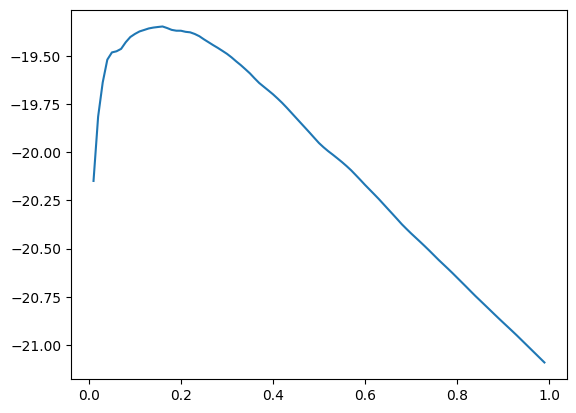

In [18]:
alpha = []
error = []

for i in range(1,100):
    alpha.append(i/100)
    lml = Lasso(alpha = (i/100))
    error.append(np.mean(cross_val_score(lml,X_train,Y_train,scoring = 'neg_mean_absolute_error', cv = 3)))

plt.plot(alpha,error)

In [19]:
err = tuple(zip(alpha,error))
df_err = pd.DataFrame(err, columns = ['alpha','error'])
df_err[df_err.error == max(df_err.error)]

,alpha,error
15,0.16,-19.348135


In [20]:
#Random Forest
from sklearn.ensemble import RandomForestRegressor
rf  = RandomForestRegressor()
np.mean(cross_val_score(rf,X_train,Y_train,scoring = 'neg_mean_absolute_error' , cv = 3))

np.float64(-15.133330769625188)

In [21]:
#Tune model using GridSearchCV
from sklearn.model_selection import GridSearchCV
parameters = {
    'n_estimators': range(10,100,10),
    'criterion': ('squared_error','absolute_error'),
    'max_features': ('sqrt','log2')   # 'auto' removed in new versions
}

gs = GridSearchCV(rf,parameters,scoring = 'neg_mean_absolute_error', cv=3)
gs.fit(X_train,Y_train)

gs.best_score_
print(gs.best_estimator_)

RandomForestRegressor(max_features='sqrt', n_estimators=70)


In [22]:
tpred_lm = lm.predict(X_test)
tpred_lml = lm_l.predict(X_test)
tpred_rf = gs.best_estimator_.predict(X_test)

In [23]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(Y_test,tpred_lm)

18.745584650967057

In [24]:
mean_absolute_error(Y_test,tpred_lml)

23.20405896228484

In [25]:
mean_absolute_error(Y_test,tpred_rf)

12.645014381591562

In [26]:
mean_absolute_error(Y_test,(tpred_lm + tpred_rf)/2)

14.49491440102185

In [27]:
import pickle
pick1 = {'model' : gs.best_estimator_}
pickle.dump( pick1, open( 'model_file' + ".p" , "wb"))

In [28]:
file_name = "model_file.p"
with open(file_name, 'rb') as pickled:
    data  = pickle.load(pickled)
    model = data['model']

model.predict(X_test.iloc[1,:].values.reshape(1,-1))

C:\Program Files\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


array([53.87142857])

In [29]:
list(X_test.iloc[1,:])

[3.6,
 1.0,
 0.0,
 0.0,
 1.0,
 34.0,
 0.0,
 0.0,
 1.0,
 4608.0,
 0.0,
 0.0,
 0.0,
 1.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 1.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 1.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 1.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 1.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 1.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,


In [30]:
df_pipe = df.copy()
X = df_pipe.drop('avg_salary', axis=1)
Y = df_pipe['avg_salary']
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

In [31]:
num_cols = ['Rating', 'age', 'desc_len', 'num_comp']
cat_cols = ['Size', 'Type of ownership', 'Industry', 'Sector', 'Revenue', 'job_state']
bin_cols = ['python_yn', 'spark', 'excel', 'hourly', 'employer_provided']

In [32]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('bin', 'passthrough' , bin_cols)
    ]
)

In [33]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

pipeline = Pipeline(steps= [
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100))
])

In [34]:
print(X_train.columns)

Index(['Job Title', 'Salary Estimate', 'Job Description', 'Rating',
       'Company Name', 'Location', 'Headquarters', 'Size', 'Founded',
       'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors',
       'hourly', 'employer_provided', 'min_salary', 'max_salary',
       'company_txt', 'job_state', 'same_state', 'age', 'python_yn', 'R_yn',
       'spark', 'aws', 'excel', 'job_simp', 'seniority', 'desc_len',
       'num_comp'],
      dtype='object')


In [35]:
pipeline.fit(X_train,Y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Rating', 'age', 'desc_len',
                                                   'num_comp']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Size', 'Type of ownership',
                                                   'Industry', 'Sector',
                                                   'Revenue', 'job_state']),
                                                 ('bin', 'passthrough',
                                                  ['python_yn', 'spark',
                                                   'excel', 'hourly',
                                                   'employer_provided'])])),
                ('model', RandomForestRegressor())])

In [36]:
pred = pipeline.predict(X_test)
pred

array([101.465,  57.165, 149.705, 113.49 , 149.1  , 123.21 , 123.9  ,
        70.515,  94.65 ,  72.165, 143.645,  87.68 , 100.89 , 119.58 ,
        71.045, 136.88 ,  81.73 ,  76.285, 106.11 , 101.825, 132.235,
       145.58 , 141.53 , 112.11 , 152.065, 106.42 ,  75.34 , 131.785,
       105.35 ,  97.12 ,  99.94 ,  53.6  , 127.12 , 123.28 , 117.93 ,
        82.58 ,  88.36 , 110.68 ,  65.56 , 126.755, 200.705, 118.195,
        76.715,  75.95 , 154.135,  79.465, 130.71 , 110.495, 120.91 ,
       100.78 , 112.305,  85.605,  83.175,  99.035, 109.155, 115.79 ,
        76.715,  72.215, 242.095, 103.455, 110.98 , 126.555, 125.395,
        93.34 ,  91.315, 105.495, 126.08 , 117.635, 123.245, 109.1  ,
       154.135, 117.635,  75.03 ,  76.34 ,  26.365,  91.315,  79.65 ,
        79.2  , 100.995,  86.025, 133.1  ,  99.805, 109.925, 128.135,
        89.455, 123.13 ,  87.655,  21.77 ,  97.205, 133.395, 109.145,
       141.325,  81.235,  57.165, 119.8  ,  90.38 ,  89.935,  56.7  ,
       104.705,  78.

In [37]:
import pickle

pickle.dump(pipeline, open("FlaskAPI/models/pipeline.pkl","wb"))

In [38]:
!pip show scikit-learn

Name: scikit-learn
Version: 1.7.2
Summary: A set of python modules for machine learning and data mining
Home-page: https://scikit-learn.org
Author: 
Author-email: 
License-Expression: BSD-3-Clause
Location: c:\program files\python310\lib\site-packages
Requires: joblib, numpy, scipy, threadpoolctl
Required-by: category_encoders, imbalanced-learn, sklearn-compat
